# 4/ Exercise solutions

In [1]:
# helper code needed for running in colab
if 'google.colab' in str(get_ipython()):
    print('Downloading plot_helpers.py to util/ (only neded for colab')
    !mkdir util; wget https://raw.githubusercontent.com/minireference/noBSLAnotebooks/master/util/plot_helpers.py -P util

In [2]:
from sympy import *
init_printing()

%matplotlib inline
import matplotlib.pyplot as mpl
from util.plot_helpers import plot_augmat, plot_plane, plot_point, plot_line, plot_vec, plot_vecs
from util.plot_helpers import autoscale_arrows

Vector = Matrix  # define alias Vector so I don't have to explain this during video
Point = Vector   # define alias Point for Vector since they're the same thing

### E4.5



In [3]:
# Given point r
r = Point([1,3,0])

# line L
pL = Point([0,0,2])
vL = Vector([1,-1,0])  # note this changed in v2.2 of LA book

# plane P
nP = Vector([1,1,1])
dP = 1

# compute the following closest distances:

In [4]:
# a)  d(r,O) = ||r||
r.norm()

In [5]:
# b)   d(L,O) = || pL - proj_{L}(pL) ||
(pL - (pL.dot(vL)/vL.norm()**2)*vL).norm()

In [6]:
# c)   d(P,O) = || proj_{nP}(pP) ||
pP = Matrix([1,0,0])
( (nP.dot(pP)/nP.norm()**2)*nP).norm()

In [7]:
# d)   u=pL-r   d(r,L)=||u - proj_{L}(u)||
u = pL - r
(u - (u.dot(vL)/vL.norm()**2)*vL).norm()

In [8]:
# e)     v=pP-r   d(r,P)=||proj_{nP}(v)||
pP = Matrix([1,0,0])
v = pP - r
( (nP.dot(v)/nP.norm()**2)*nP).norm()

In [9]:
#f)  d(L,P)
# STEP1: check relative orientation of L and P
print('vL·nP =', vL.dot(nP), 'so line is parallel to plane. OK to proceed...')
# STEP2: find vector w=pP-pL arbitrary points on plane nad line,
pP = Matrix([1,0,0])
w = pP - pL
# then compute component of w in perp. to the plane    d(L,P)=||proj_{nP}(w)||
( (nP.dot(w)/nP.norm()**2)*nP).norm()

vL·nP = 0 so line is parallel to plane. OK to proceed...


In [10]:
# # debug viz to make sure L parallel to P
# plot_vec(5*vL, at=pL, color='b')
# plot_vec(-5*vL, at=pL, color='b')
# plot_vec(w, color='r', at=pL)
# plot_plane(nP,dP)

### E4.7


In [11]:
# Setup the variables of the exercise:
p = Point([10,10,10])
pL1 = Point([3,0,5])   # an arbitrary point on L1
pL2 = Point([6,0,0])   # an arbitrary point on L2
d = Vector([1,-2,0])   # direction vector of L1 and L2



a) Projection of $p$ onto $\ell_1$

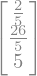

In [12]:
# define a vector from a point on L1 to p:
v1 = p - pL1

# proj_{L1}(p) = proj_{L1}(v1) + pL1 
p_proj_L1 = (d.dot(v1)/d.norm()**2)*d + pL1
p_proj_L1

^ This is the point on the line $\ell_1$ that is closes to the point $p$

b) (shortest) distance form $p$ to $\ell_1$

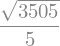

In [13]:
# d(p, L1) = subtract from v1 the part that is perp to L1 and compute the length:
(v1 - (d.dot(v1)/d.norm()**2)*d).norm()

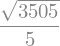

In [14]:
# ... or compute the distance directly:
(p_proj_L1-p).norm()

In [15]:
(p_proj_L1-p).norm().n()  # numeric approx.

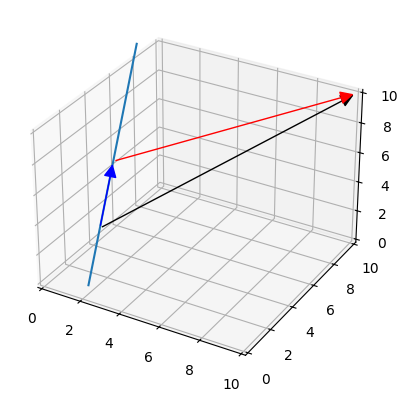

In [17]:
plot_line(d, pL1)  # Line L1

# vector v1 and it's decomposition into parallel-to-L1 and perp-to-L1 components
plot_vec(v1, at=pL1)
plot_vec(p_proj_L1-pL1, at=pL1,     color='b')
plot_vec(p-p_proj_L1, at=p_proj_L1, color='r')

ax = mpl.gca()
ax.set_xlim([0,10])
ax.set_ylim([0,10])
ax.set_zlim([0,10]);

Answer to a) is the tip of the blue vector; answer to b) is the length of the red vector.

Use a similar approach for c) and d) 

In [18]:
# define a vector from a point on L2 to p:
v2 = p - pL2

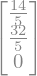

In [19]:
# p_proj_L2 = 
(d.dot(v2)/d.norm()**2)*d + pL2

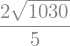

In [20]:
# d(p, L2) = 
(v2 - (d.dot(v2)/d.norm()**2)*d).norm()

In [21]:
(v2 - (d.dot(v2)/d.norm()**2)*d).norm().n()

e) distance $\ell_1$ to $\ell_2$

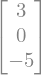

In [22]:
# first define a vector from a point on L1 to a point on L2:
v3 = pL2 - pL1
v3

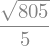

In [23]:
# d(L1, L2) = 
d_L1L2 = (v3 - (d.dot(v3)/d.norm()**2)*d).norm()
d_L1L2

In [24]:
d_L1L2.n()